<div style="width: 100%; margin-bottom: 20px;">
    <img src="../assets/banner.png" style="width: 100%; border-radius: 10px; height: 300px; object-fit: cover;">
</div>

# Phase 2 – Analyse Exploratoire des Données (EDA)
## Projet ML : Prédiction des Tempêtes Géomagnétiques

**Réalisé par :** 
- AMEZIANE Oumaima
- ROHAND Douae
- MOHITO Raihana
  
**Date :** 2025-2026  
**Cours :** Machine Learning – 2ème année Cycle Ingénieurs GI  
**Encadrant :** Pr. Y. EL YOUNOUSSI

---

L'objectif de ce notebook est d'explorer en profondeur le dataset de météo spatiale pour identifier les signaux
prédictifs des tempêtes géomagnétiques (Kp ≥ 5).
Cette **Phase** se concentre sur :
- L'analyse univariée des distributions (physiques et temporelles)
- L'étude du déséquilibre des classes et son impact potentiel
- L'identification des variables les plus discriminantes (features signaux)
- La recherche de corrélations et de multicolinéarité

## 0. Imports et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Style global des graphiques (Alignement Phase 1)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# Configuration des couleurs
COLOR_STORM = '#FF8C00'  # Orange
COLOR_CALM    = '#1a237e'   # Bleu nuit
COLOR_ACCENT  = '#76ff03'   # Vert aurore
COLOR_MAIN = COLOR_CALM
COLOR_ACC  = COLOR_STORM

TARGET = 'is_storm'
target = TARGET  # Alias pour compatibilité

# Variables globales pour l'analyse de la cible
vc_target = None   # Sera calculé après chargement de df
pct_target = None
ratio = None



In [2]:
# --- Chargement ---
# Adapter le chemin selon votre structure
df = pd.read_csv('../data/dataset.csv', parse_dates=['timestamp'])

# Aperçu rapide
print(f'Shape : {df.shape}')
print(f'Colonnes : {df.columns.tolist()}')
df.head(3)
# Calcul des variables pour le déséquilibre
vc_target = df[target].value_counts()
pct_target = df[target].value_counts(normalize=True) * 100
ratio = vc_target[0] / vc_target[1] if 1 in vc_target else 1


Shape : (43207, 15)
Colonnes : ['timestamp', 'solar_wind_speed', 'solar_wind_density', 'bz_component', 'solar_wind_pressure', 'bz_min_3h', 'dst_index', 'month', 'sin_month', 'cos_month', 'season', 'hour_interval', 'bz_negative', 'is_solar_maximum', 'is_storm']


**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

In [3]:
# Types et valeurs manquantes globales
info = pd.DataFrame({
    'dtype'   : df.dtypes,
    'n_null'  : df.isnull().sum(),
    'pct_null': (df.isnull().mean() * 100).round(2),
    'n_unique': df.nunique()
})
print(info.to_string())

                              dtype  n_null  pct_null  n_unique
timestamp            datetime64[us]       0       0.0     43207
solar_wind_speed            float64       0       0.0       509
solar_wind_density          float64       0       0.0       420
bz_component                float64       0       0.0       352
solar_wind_pressure         float64       0       0.0     21401
bz_min_3h                   float64       0       0.0       321
dst_index                   float64       0       0.0       183
month                         int64       0       0.0        12
sin_month                   float64       0       0.0        11
cos_month                   float64       0       0.0        11
season                          str       0       0.0         4
hour_interval                   str       0       0.0         8
bz_negative                 float64       0       0.0         2
is_solar_maximum              int64       0       0.0         2
is_storm                      int64     

**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

## 1. Analyse Univariée

In [4]:
NUM_COLS = [
    'solar_wind_speed',
    'solar_wind_density',
    'bz_component',
    'solar_wind_pressure',
    'bz_min_3h',
    'dst_index',
    'month',
    'sin_month',
    'cos_month',
]

# Statistiques descriptives
desc = df[NUM_COLS].describe().T
desc['skewness'] = df[NUM_COLS].skew().round(3)
desc['kurtosis'] = df[NUM_COLS].kurt().round(3)
print('=== Statistiques descriptives — variables numériques ===')
display(desc.round(3))

=== Statistiques descriptives — variables numériques ===


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
solar_wind_speed,43207.0,410.104,86.251,259.0,344.000,391.0,461.000,846.0,0.939,0.554
solar_wind_density,43207.0,6.190,4.734,0.1,3.200,4.9,7.700,84.4,2.923,16.281
bz_component,43207.0,-0.130,2.757,-32.4,-1.600,-0.2,1.200,31.3,0.247,7.990
solar_wind_pressure,43207.0,948974.216,664435.311,18576.1,562877.700,787989.6,1126735.150,12110502.8,3.635,25.769
bz_min_3h,43207.0,-1.248,2.614,-32.4,-2.500,-1.2,0.100,27.5,-0.398,9.015
dst_index,43207.0,-8.622,14.622,-213.0,-15.000,-6.0,0.000,42.0,-2.058,13.081
month,43207.0,6.526,3.447,1.0,4.000,7.0,10.000,12.0,-0.010,-1.211
sin_month,43207.0,-0.005,0.707,-1.0,-0.866,-0.0,0.500,1.0,0.011,-1.500
cos_month,43207.0,-0.002,0.707,-1.0,-0.866,-0.0,0.866,1.0,0.010,-1.501


**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

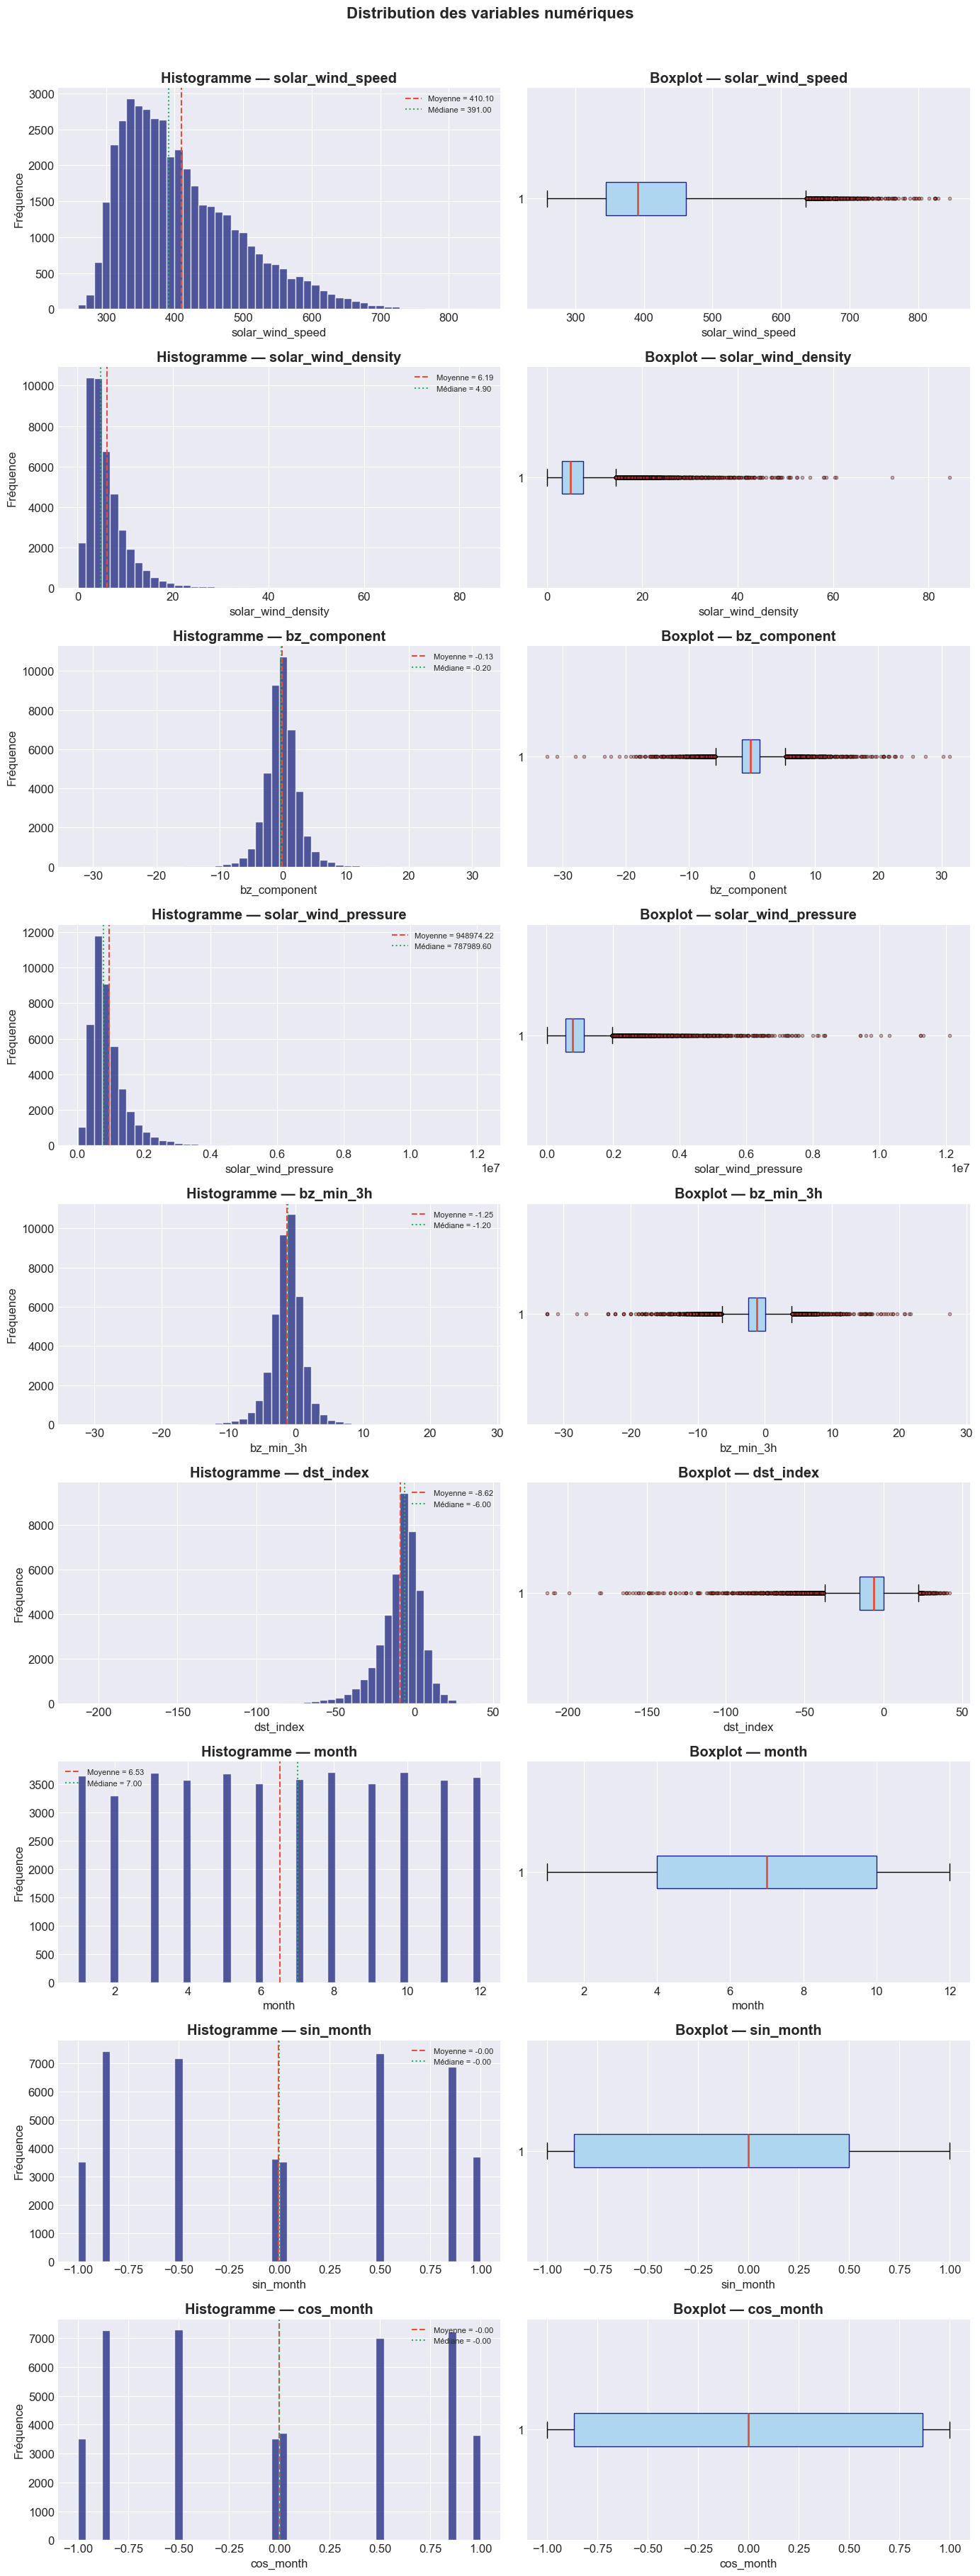

In [5]:
# Histogrammes + boxplots pour chaque variable numérique
fig, axes = plt.subplots(len(NUM_COLS), 2, figsize=(14, 4 * len(NUM_COLS)))
fig.suptitle('Distribution des variables numériques', fontsize=16, fontweight='bold', y=1.01)

for i, col in enumerate(NUM_COLS):
    # Histogramme
    ax_hist = axes[i, 0]
    ax_hist.hist(df[col].dropna(), bins=50, color=COLOR_MAIN, alpha=0.75, edgecolor='white')
    ax_hist.axvline(df[col].mean(),   color='#E74C3C', linestyle='--', linewidth=1.5, label=f'Moyenne = {df[col].mean():.2f}')
    ax_hist.axvline(df[col].median(), color='#27AE60', linestyle=':',  linewidth=1.5, label=f'Médiane = {df[col].median():.2f}')
    ax_hist.set_title(f'Histogramme — {col}', fontweight='bold')
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel('Fréquence')
    ax_hist.legend(fontsize=8)

    # Boxplot
    ax_box = axes[i, 1]
    ax_box.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                   boxprops=dict(facecolor='#AED6F1', color=COLOR_MAIN),
                   medianprops=dict(color='#E74C3C', linewidth=2),
                   flierprops=dict(marker='o', markerfacecolor='#E74C3C', markersize=3, alpha=0.4))
    ax_box.set_title(f'Boxplot — {col}', fontweight='bold')
    ax_box.set_xlabel(col)

plt.tight_layout()
plt.savefig('../data/univariate_numeric.png', bbox_inches='tight')
plt.show()


**Interprétation :**
- `solar_wind_speed` : distribution légèrement asymétrique à droite, valeurs entre ~250 et 900 km/s.
- `bz_component` et `bz_min_3h` : distributions centrées autour de 0, valeurs négatives associées aux tempêtes.
- `dst_index` : valeurs négatives importantes lors des tempêtes (critère Dst < -50 nT).
- `solar_wind_pressure` : forte asymétrie positive — quelques pics extrêmes.

### 1.2 Variables catégorielles

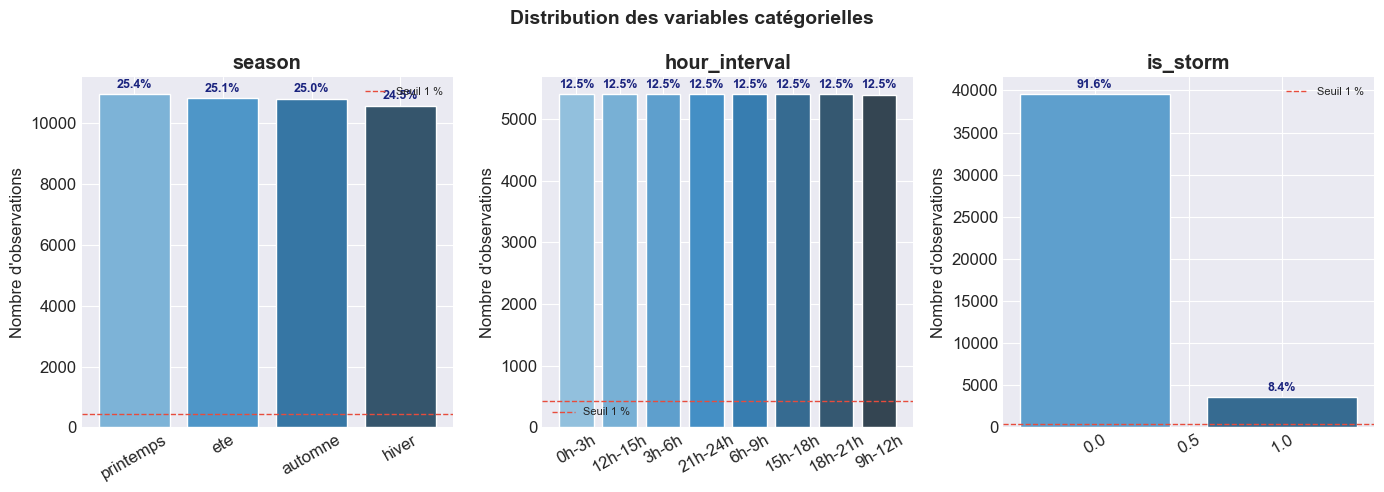

In [6]:
CAT_COLS = [
    'season',
    'hour_interval',
    
   
    'is_storm',
]
BIN_COLS = ['bz_negative', 'is_solar_maximum']

fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(14, 5))
fig.suptitle('Distribution des variables catégorielles', fontsize=14, fontweight='bold')

for i, col in enumerate(CAT_COLS):
    vc = df[col].value_counts()
    pct = (vc / len(df) * 100).round(1)
    bars = axes[i].bar(vc.index, vc.values, color=sns.color_palette('Blues_d', len(vc)), edgecolor='white')
    # Annotation modalités rares (< 1 %)
    for bar, (mod, p) in zip(bars, pct.items()):
        color = '#E74C3C' if p < 1 else COLOR_MAIN
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vc.values)*0.01,
                     f'{p}%', ha='center', va='bottom', fontsize=9, color=color, fontweight='bold')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Nombre d\'observations')
    axes[i].tick_params(axis='x', rotation=30)
    # Ligne seuil 1 %
    axes[i].axhline(len(df) * 0.01, color='#E74C3C', linestyle='--', linewidth=1, label='Seuil 1 %')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/univariate_categorical.png', bbox_inches='tight')
plt.show()

**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

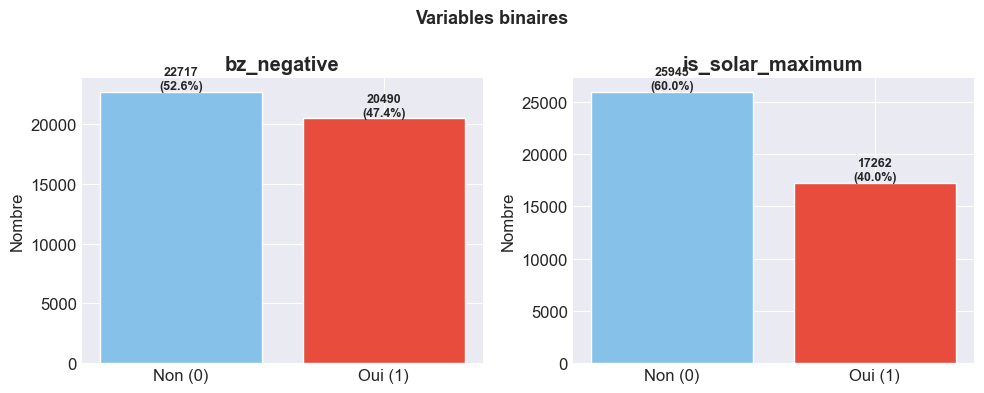


=== Modalités rares (< 1%) ===
season : aucune modalité rare
hour_interval : aucune modalité rare
is_storm : aucune modalité rare


In [7]:
# Variables binaires
fig, axes = plt.subplots(1, len(BIN_COLS), figsize=(10, 4))
fig.suptitle('Variables binaires', fontsize=13, fontweight='bold')
for i, col in enumerate(BIN_COLS):
    vc = df[col].value_counts()
    axes[i].bar(['Non (0)', 'Oui (1)'], vc.values, color=['#85C1E9', '#E74C3C'], edgecolor='white')
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + max(vc.values)*0.01, f'{v}\n({v/len(df)*100:.1f}%)',
                     ha='center', fontsize=9, fontweight='bold')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Nombre')
plt.tight_layout()
plt.show()

# Tableau récap modalités rares
print('\n=== Modalités rares (< 1%) ===')
for col in CAT_COLS:
    pct = df[col].value_counts(normalize=True) * 100
    rare = pct[pct < 1]
    if len(rare):
        print(f'{col} : {rare.to_dict()}')
    else:
        print(f'{col} : aucune modalité rare')

**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

## 2. Analyse du Déséquilibre des Classes

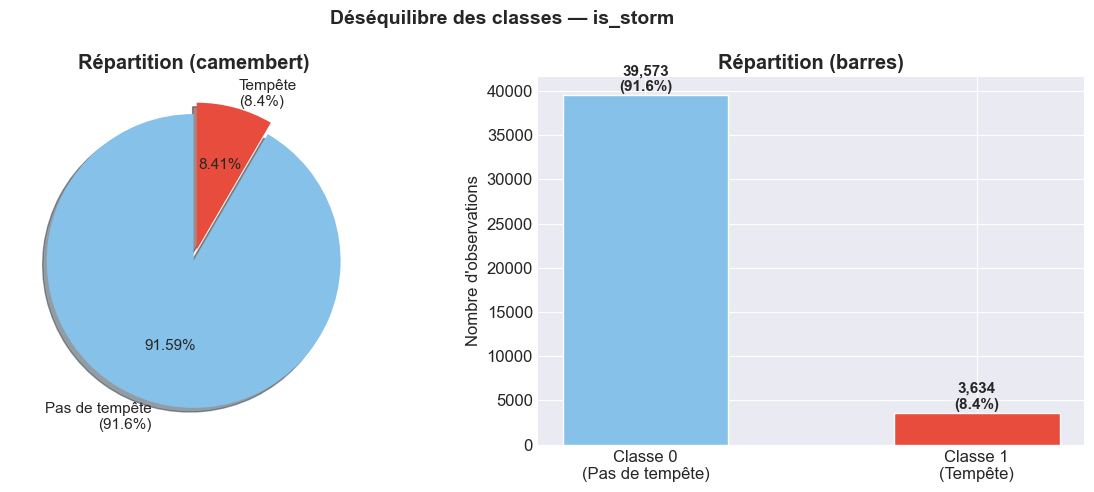

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Déséquilibre des classes — is_storm', fontsize=14, fontweight='bold')

# Camembert
labels = [f'Pas de tempête\n({pct_target[0]:.1f}%)', f'Tempête\n({pct_target[1]:.1f}%)']
colors = ['#85C1E9', '#E74C3C']
axes[0].pie(vc_target.values, labels=labels, colors=colors, autopct='%1.2f%%',
            startangle=90, explode=(0, 0.08), shadow=True,
            textprops={'fontsize': 11})
axes[0].set_title('Répartition (camembert)', fontweight='bold')

# Barres
bars = axes[1].bar(['Classe 0\n(Pas de tempête)', 'Classe 1\n(Tempête)'],
                    vc_target.values, color=colors, edgecolor='white', width=0.5)
for bar, (cls, cnt) in zip(bars, vc_target.items()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vc_target.values)*0.01,
                 f'{cnt:,}\n({pct_target[cls]:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Répartition (barres)', fontweight='bold')
axes[1].set_ylabel('Nombre d\'observations')

plt.tight_layout()
plt.savefig('../data/class_imbalance.png', bbox_inches='tight')
plt.show()

**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

In [9]:
# Statistiques descriptives séparées par classe
print('=== Statistiques descriptives par classe ===')
for cls in [0, 1]:
    label = 'TEMPÊTE' if cls == 1 else 'Pas de tempête'
    print(f'\n--- Classe {cls} : {label} ---')
    display(df[df[target] == cls][NUM_COLS].describe().T.round(3))

=== Statistiques descriptives par classe ===

--- Classe 0 : Pas de tempête ---


,count,mean,std,min,25%,50%,75%,max
solar_wind_speed,39573.0,402.487,80.185,259.0,341.000,385.0,450.000,829.0
solar_wind_density,39573.0,6.200,4.573,0.1,3.200,4.9,7.800,60.4
bz_component,39573.0,-0.116,2.516,-16.9,-1.500,-0.2,1.200,20.9
solar_wind_pressure,39573.0,912212.708,580356.893,18576.1,558018.500,775699.2,1094415.600,11320960.0
bz_min_3h,39573.0,-1.189,2.355,-16.9,-2.400,-1.1,0.100,17.3
dst_index,39573.0,-7.100,11.999,-92.0,-13.000,-6.0,1.000,42.0
month,39573.0,6.507,3.460,1.0,4.000,7.0,10.000,12.0
sin_month,39573.0,0.001,0.698,-1.0,-0.500,-0.0,0.500,1.0
cos_month,39573.0,-0.002,0.716,-1.0,-0.866,0.0,0.866,1.0



--- Classe 1 : TEMPÊTE ---


,count,mean,std,min,25%,50%,75%,max
solar_wind_speed,3634.0,493.044,104.523,292.0,410.000,487.0,573.000,846.0
solar_wind_density,3634.0,6.083,6.218,0.1,2.700,4.2,7.200,84.4
bz_component,3634.0,-0.283,4.626,-32.4,-2.300,-0.4,1.500,31.3
solar_wind_pressure,3634.0,1349294.300,1185990.241,31584.4,655468.750,993689.4,1638100.175,12110502.8
bz_min_3h,3634.0,-1.891,4.514,-32.4,-3.500,-1.7,0.000,27.5
dst_index,3634.0,-25.193,25.971,-213.0,-36.000,-22.0,-9.000,38.0
month,3634.0,6.729,3.298,1.0,4.000,8.0,9.000,12.0
sin_month,3634.0,-0.065,0.794,-1.0,-0.866,-0.0,0.866,1.0
cos_month,3634.0,0.006,0.605,-1.0,-0.500,-0.0,0.500,1.0


**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

## 3. Analyse Bivariée

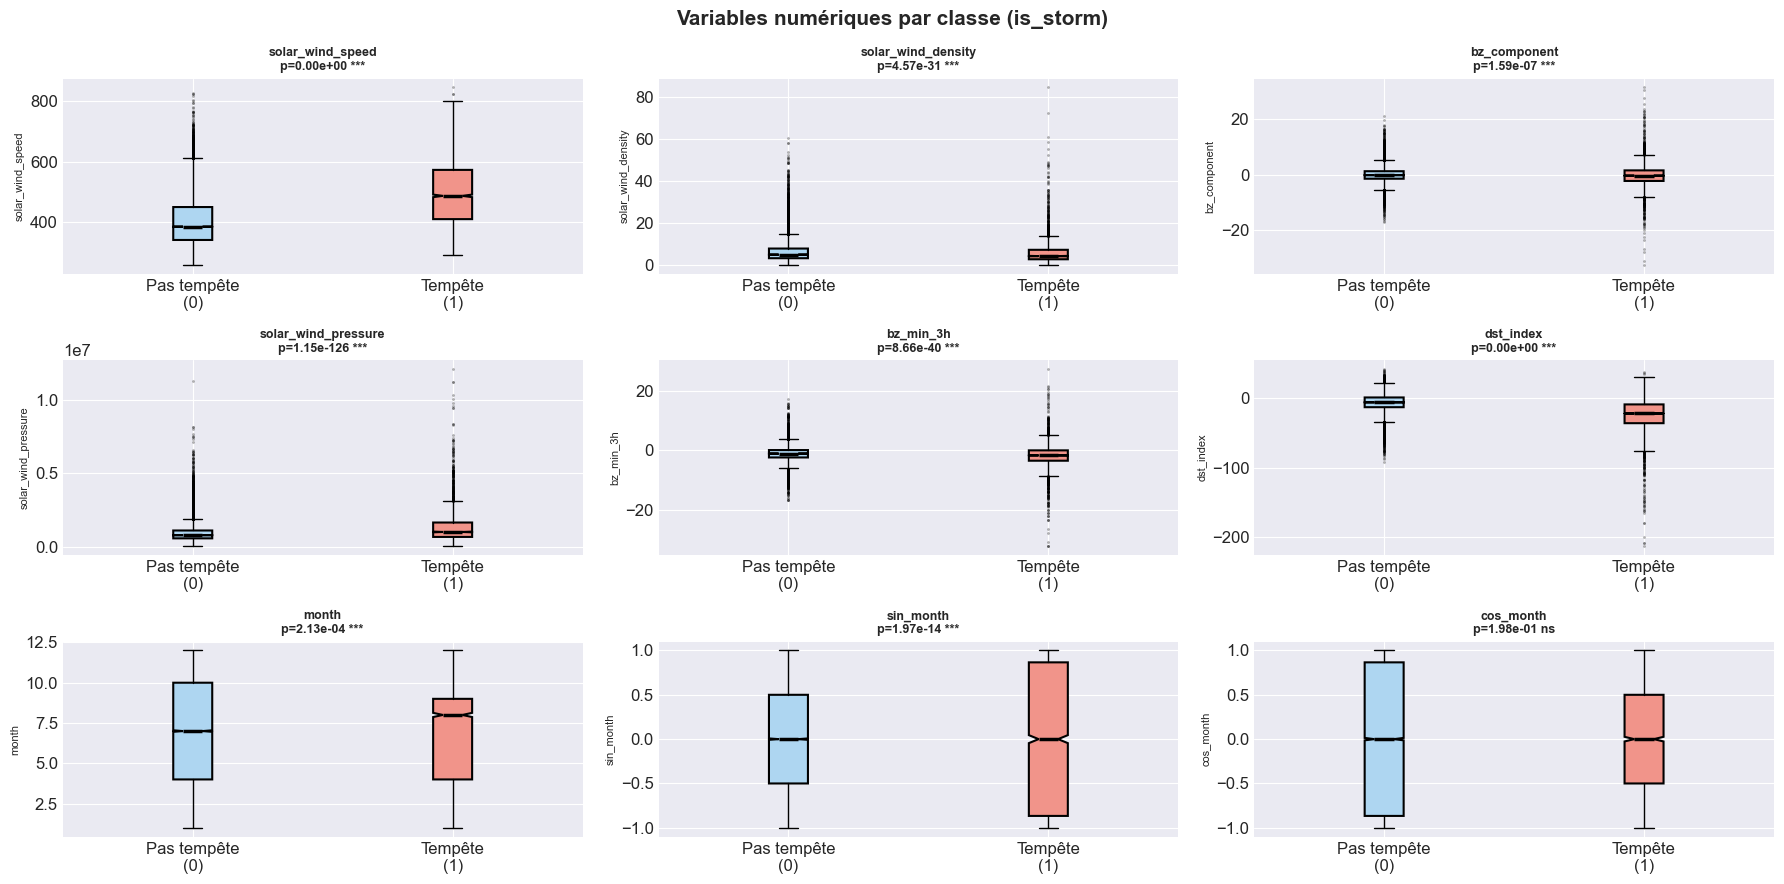

Significativité : *** p<0.001 | ** p<0.01 | * p<0.05 | ns non significatif


In [10]:
fig, axes = plt.subplots(3, 3, figsize=(18, 9))
fig.suptitle('Variables numériques par classe (is_storm)', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    data_0 = df[df[target] == 0][col].dropna()
    data_1 = df[df[target] == 1][col].dropna()
    bp = axes[i].boxplot(
        [data_0, data_1],
        labels=['Pas tempête\n(0)', 'Tempête\n(1)'],
        patch_artist=True,
        notch=True,
        boxprops=dict(linewidth=1.5),
        medianprops=dict(linewidth=2.5, color='black'),
        flierprops=dict(marker='.', markersize=2, alpha=0.3)
    )
    bp['boxes'][0].set_facecolor('#AED6F1')
    bp['boxes'][1].set_facecolor('#F1948A')

    # Test de Mann-Whitney pour significativité
    stat, pval = stats.mannwhitneyu(data_0, data_1, alternative='two-sided')
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
    axes[i].set_title(f'{col}\np={pval:.2e} {sig}', fontweight='bold', fontsize=9)
    axes[i].set_ylabel(col, fontsize=8)

plt.tight_layout()
plt.savefig('../data/bivariate_numeric_target.png', bbox_inches='tight')
plt.show()
print('Significativité : *** p<0.001 | ** p<0.01 | * p<0.05 | ns non significatif')

**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

### 3.2 Catégorielle × Cible (taux de tempêtes par modalité)

=== Tableau croisé : season × is_storm ===


is_storm,0,1
season,,
automne,87.43,12.57
ete,95.78,4.22
hiver,94.58,5.42
printemps,88.67,11.33


=== Tableau croisé : hour_interval × is_storm ===


is_storm,0,1
hour_interval,,
0h-3h,91.53,8.47
12h-15h,91.73,8.27
15h-18h,91.83,8.17
18h-21h,91.69,8.31
21h-24h,91.67,8.33
3h-6h,91.36,8.64
6h-9h,91.35,8.65
9h-12h,91.57,8.43


=== Tableau croisé : is_storm × is_storm ===


is_storm,0,1
is_storm,,
0,100.0,0.0
1,0.0,100.0


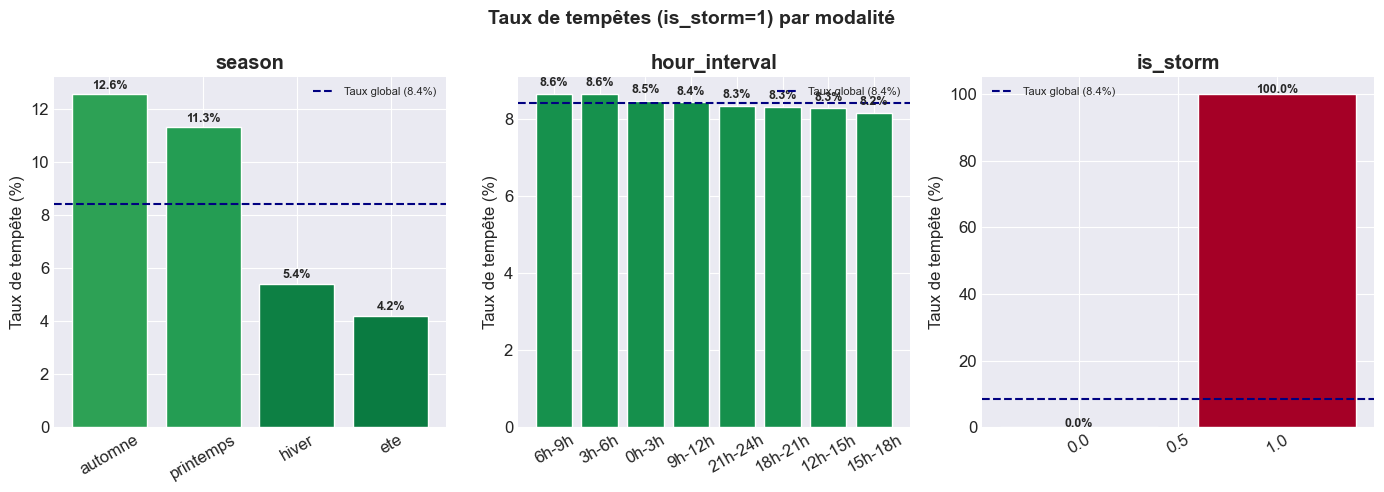

In [11]:
fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(14, 5))
fig.suptitle('Taux de tempêtes (is_storm=1) par modalité', fontsize=14, fontweight='bold')

for i, col in enumerate(CAT_COLS):
    # Tableau croisé
    ct = pd.crosstab(df[col], df[target], normalize='index') * 100
    print(f'=== Tableau croisé : {col} × is_storm ===')
    display(ct.round(2))

    rate = ct[1] if 1 in ct.columns else pd.Series(dtype=float)
    rate_sorted = rate.sort_values(ascending=False)
    bars = axes[i].bar(rate_sorted.index, rate_sorted.values,
                        color=[plt.cm.RdYlGn_r(v/100) for v in rate_sorted.values],
                        edgecolor='white')
    for bar, val in zip(bars, rate_sorted.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[i].axhline(pct_target.get(1, 0), color='navy', linestyle='--',
                     linewidth=1.5, label=f'Taux global ({pct_target.get(1,0):.1f}%)')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel('Taux de tempête (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/bivariate_cat_target.png', bbox_inches='tight')
plt.show()

**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

### 3.3 Matrice de corrélation (numérique × numérique)

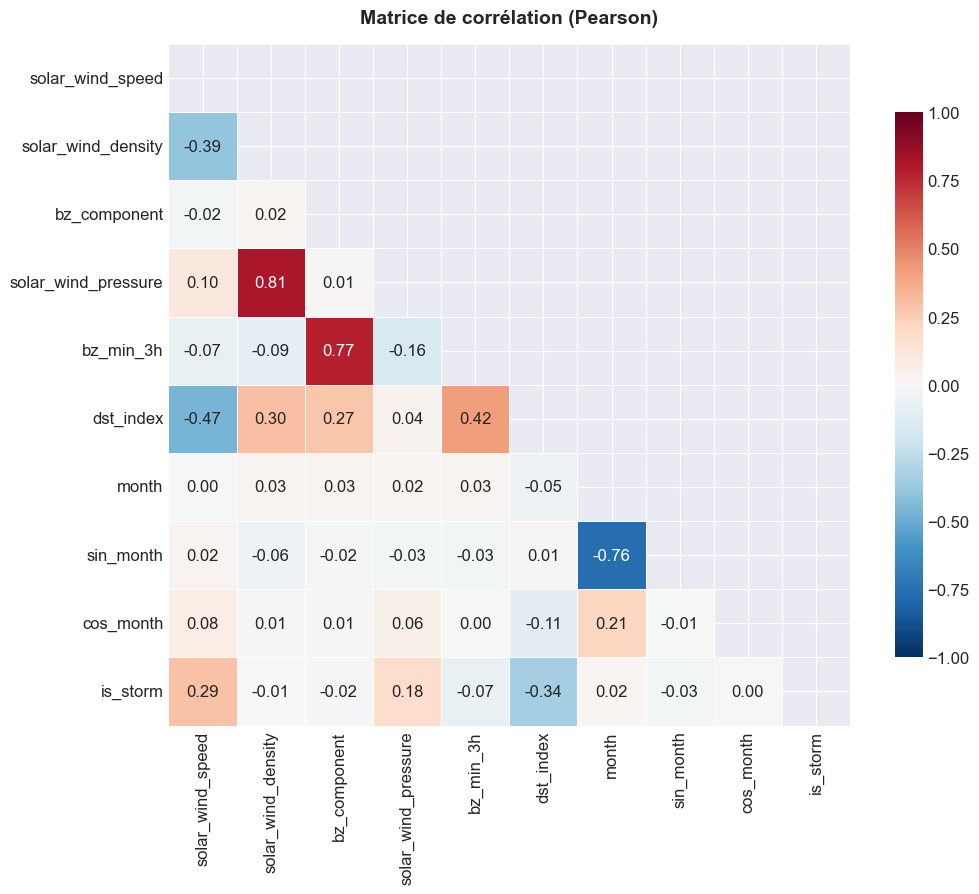


=== Paires fortement corrélées (|r| > 0.8) ===
  solar_wind_pressure ↔ solar_wind_density : r = 0.815


In [12]:
corr_matrix = df[NUM_COLS + [target]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matrice de corrélation (Pearson)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/correlation_matrix.png', bbox_inches='tight')
plt.show()

# Features fortement corrélées entre elles (|r| > 0.8)
print('\n=== Paires fortement corrélées (|r| > 0.8) ===')
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong = [(col, row, upper.loc[row, col])
          for col in upper.columns for row in upper.index
          if pd.notna(upper.loc[row, col]) and abs(upper.loc[row, col]) > 0.8 and row != target and col != target]
if strong:
    for c1, c2, r in strong:
        print(f'  {c1} ↔ {c2} : r = {r:.3f}')
else:
    print('  Aucune paire avec |r| > 0.8 détectée.')

**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

### 3.4 Corrélation avec la cible (features signaux)

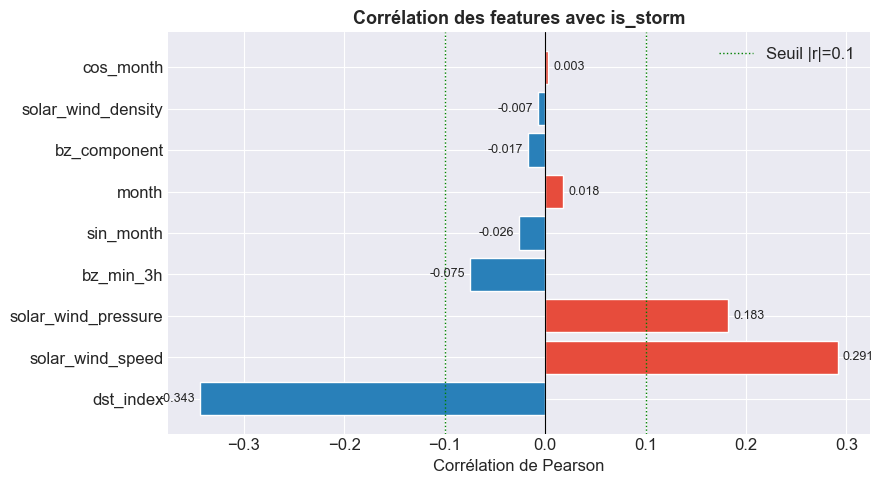


=== Features signaux (|r| > 0.1 avec is_storm) ===
  dst_index                      r = -0.343  ↓ corrélation négative
  solar_wind_speed               r = +0.291  ↑ corrélation positive
  solar_wind_pressure            r = +0.183  ↑ corrélation positive


In [13]:
corr_target = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E74C3C' if v > 0 else '#2980B9' for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.1, color='green', linestyle=':', linewidth=1, label='Seuil |r|=0.1')
ax.axvline(-0.1, color='green', linestyle=':', linewidth=1)
for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_title('Corrélation des features avec is_storm', fontsize=13, fontweight='bold')
ax.set_xlabel('Corrélation de Pearson')
ax.legend()
plt.tight_layout()
plt.savefig('../data/feature_correlation_target.png', bbox_inches='tight')
plt.show()

print('\n=== Features signaux (|r| > 0.1 avec is_storm) ===')
signals = corr_target[abs(corr_target) > 0.1]
for feat, r in signals.items():
    direction = '↑ corrélation positive' if r > 0 else '↓ corrélation négative'
    print(f'  {feat:30s} r = {r:+.3f}  {direction}')

**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

## 4. Identification des Signaux Prédictifs

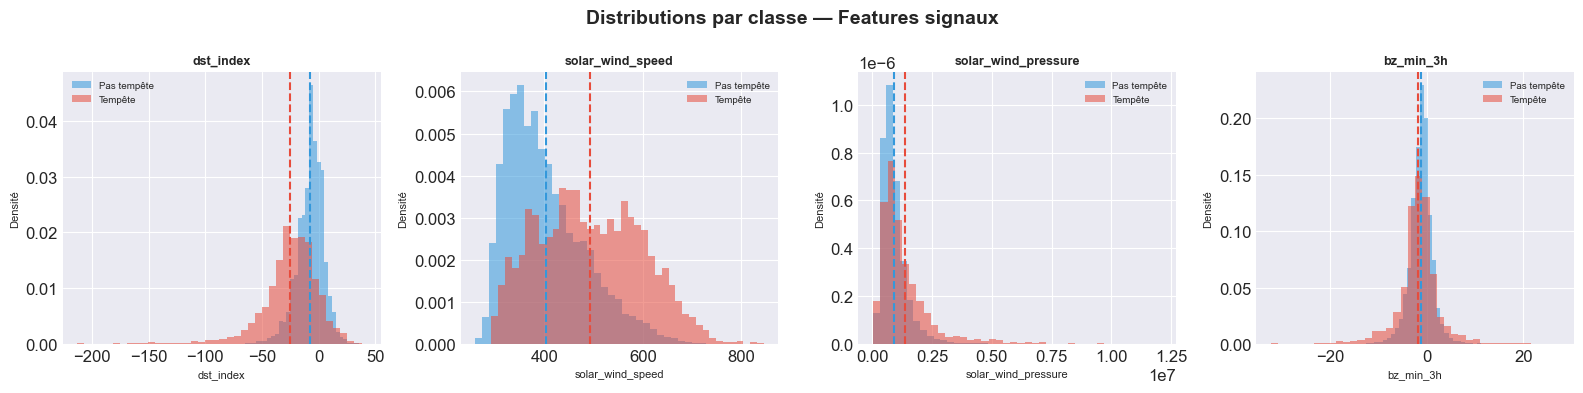

In [14]:
# Top features signaux (|r| > 0.05 ou choix expert)
signal_cols = corr_target[abs(corr_target) > 0.05].index.tolist()
if not signal_cols:
    signal_cols = NUM_COLS[:6]  # fallback

n = len(signal_cols)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
if n == 1:
    axes = [axes]
fig.suptitle('Distributions par classe — Features signaux', fontsize=14, fontweight='bold')

for ax, col in zip(axes, signal_cols):
    for cls, color, label in [(0, '#3498DB', 'Pas tempête'), (1, '#E74C3C', 'Tempête')]:
        vals = df[df[target] == cls][col].dropna()
        ax.hist(vals, bins=40, alpha=0.55, color=color, label=label, density=True)
        ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5)
    ax.set_title(col, fontweight='bold', fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Densité', fontsize=8)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('../data/signal_features_distributions.png', bbox_inches='tight')
plt.show()

**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

In [15]:
# Tableau comparatif des moyennes par classe
summary = pd.DataFrame()
for col in NUM_COLS:
    m0 = df[df[target] == 0][col].mean()
    m1 = df[df[target] == 1][col].mean()
    diff_pct = ((m1 - m0) / abs(m0) * 100) if m0 != 0 else np.nan
    stat, pval = stats.mannwhitneyu(
        df[df[target]==0][col].dropna(),
        df[df[target]==1][col].dropna(),
        alternative='two-sided'
    )
    summary.loc[col, 'Moyenne Classe 0'] = round(m0, 3)
    summary.loc[col, 'Moyenne Classe 1'] = round(m1, 3)
    summary.loc[col, 'Diff (%)']          = round(diff_pct, 1)
    summary.loc[col, 'Corr. Pearson']     = round(corr_matrix.loc[col, target], 3)
    summary.loc[col, 'p-value (Mann-W)']  = f'{pval:.2e}'
    summary.loc[col, 'Signal fort ?']     = 'OUI' if pval < 0.05 and abs(corr_matrix.loc[col, target]) > 0.05 else 'NON'

print('=== Tableau comparatif — features × classes ===')
display(summary)

=== Tableau comparatif — features × classes ===


,Moyenne Classe 0,Moyenne Classe 1,Diff (%),Corr. Pearson,p-value (Mann-W),Signal fort ?
solar_wind_speed,402.487,493.044,22.5,0.291,0.00e+00,OUI
solar_wind_density,6.200,6.083,-1.9,-0.007,4.57e-31,NON
bz_component,-0.116,-0.283,-143.2,-0.017,1.59e-07,NON
solar_wind_pressure,912212.708,1349294.300,47.9,0.183,1.15e-126,OUI
bz_min_3h,-1.189,-1.891,-59.0,-0.075,8.66e-40,OUI
dst_index,-7.100,-25.193,-254.8,-0.343,0.00e+00,OUI
month,6.507,6.729,3.4,0.018,2.13e-04,NON
sin_month,0.001,-0.065,-12246.7,-0.026,1.97e-14,NON
cos_month,-0.002,0.006,362.1,0.003,1.98e-01,NON


**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

### 4.2 Analyse temporelle : distribution des tempêtes dans le temps

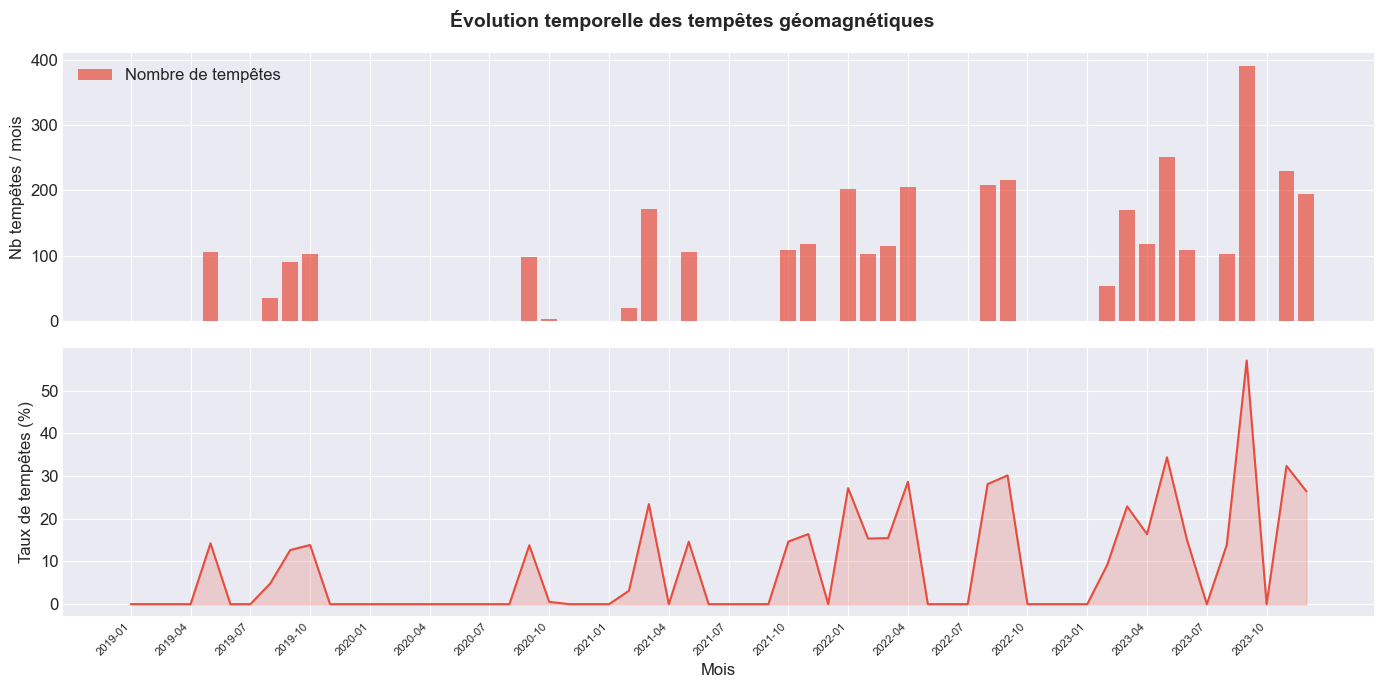

In [16]:
if 'timestamp' in df.columns:
    df_time = df.copy()
    df_time['year_month'] = df_time['timestamp'].dt.to_period('M')
    monthly = df_time.groupby('year_month')[target].agg(['sum', 'count'])
    monthly['rate'] = monthly['sum'] / monthly['count'] * 100

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle('Évolution temporelle des tempêtes géomagnétiques', fontsize=14, fontweight='bold')

    x = range(len(monthly))
    axes[0].bar(x, monthly['sum'], color='#E74C3C', alpha=0.7, label='Nombre de tempêtes')
    axes[0].set_ylabel('Nb tempêtes / mois')
    axes[0].legend()

    axes[1].plot(x, monthly['rate'], color='#E74C3C', linewidth=1.5)
    axes[1].fill_between(x, monthly['rate'], alpha=0.2, color='#E74C3C')
    axes[1].set_ylabel('Taux de tempêtes (%)')
    axes[1].set_xlabel('Mois')

    tick_step = max(1, len(monthly) // 20)
    axes[1].set_xticks(x[::tick_step])
    axes[1].set_xticklabels([str(p) for p in monthly.index[::tick_step]], rotation=45, ha='right', fontsize=8)

    plt.tight_layout()
    plt.savefig('../data/temporal_storm_rate.png', bbox_inches='tight')
    plt.show()
else:
    print('Colonne timestamp non disponible.')

**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

## 5. Analyse par Sous-Groupes

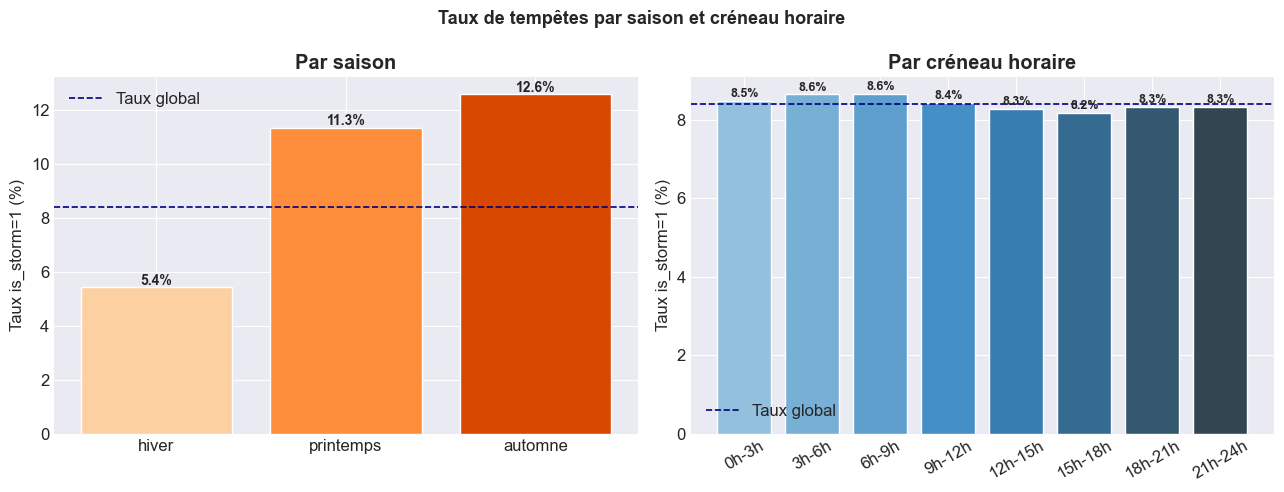

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Taux de tempêtes par saison et créneau horaire', fontsize=13, fontweight='bold')

# Par saison
season_rate = df.groupby('season')[target].mean() * 100
season_order = ['hiver', 'printemps', 'été', 'automne']
season_rate = season_rate.reindex([s for s in season_order if s in season_rate.index])
bars = axes[0].bar(season_rate.index, season_rate.values,
                    color=sns.color_palette('Oranges', len(season_rate)), edgecolor='white')
axes[0].axhline(pct_target.get(1, 0), color='navy', linestyle='--', linewidth=1.2, label='Taux global')
for bar, val in zip(bars, season_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Par saison', fontweight='bold')
axes[0].set_ylabel('Taux is_storm=1 (%)')
axes[0].legend()

# Par créneau horaire
hour_rate = df.groupby('hour_interval')[target].mean() * 100
hour_order = ['0h-3h', '3h-6h', '6h-9h', '9h-12h', '12h-15h', '15h-18h', '18h-21h', '21h-24h']
hour_rate = hour_rate.reindex([h for h in hour_order if h in hour_rate.index])
bars2 = axes[1].bar(hour_rate.index, hour_rate.values,
                     color=sns.color_palette('Blues_d', len(hour_rate)), edgecolor='white')
axes[1].axhline(pct_target.get(1, 0), color='navy', linestyle='--', linewidth=1.2, label='Taux global')
for bar, val in zip(bars2, hour_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Par créneau horaire', fontweight='bold')
axes[1].set_ylabel('Taux is_storm=1 (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/storm_rate_by_group.png', bbox_inches='tight')
plt.show()

**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.

## 6. Visualisations des Corrélations

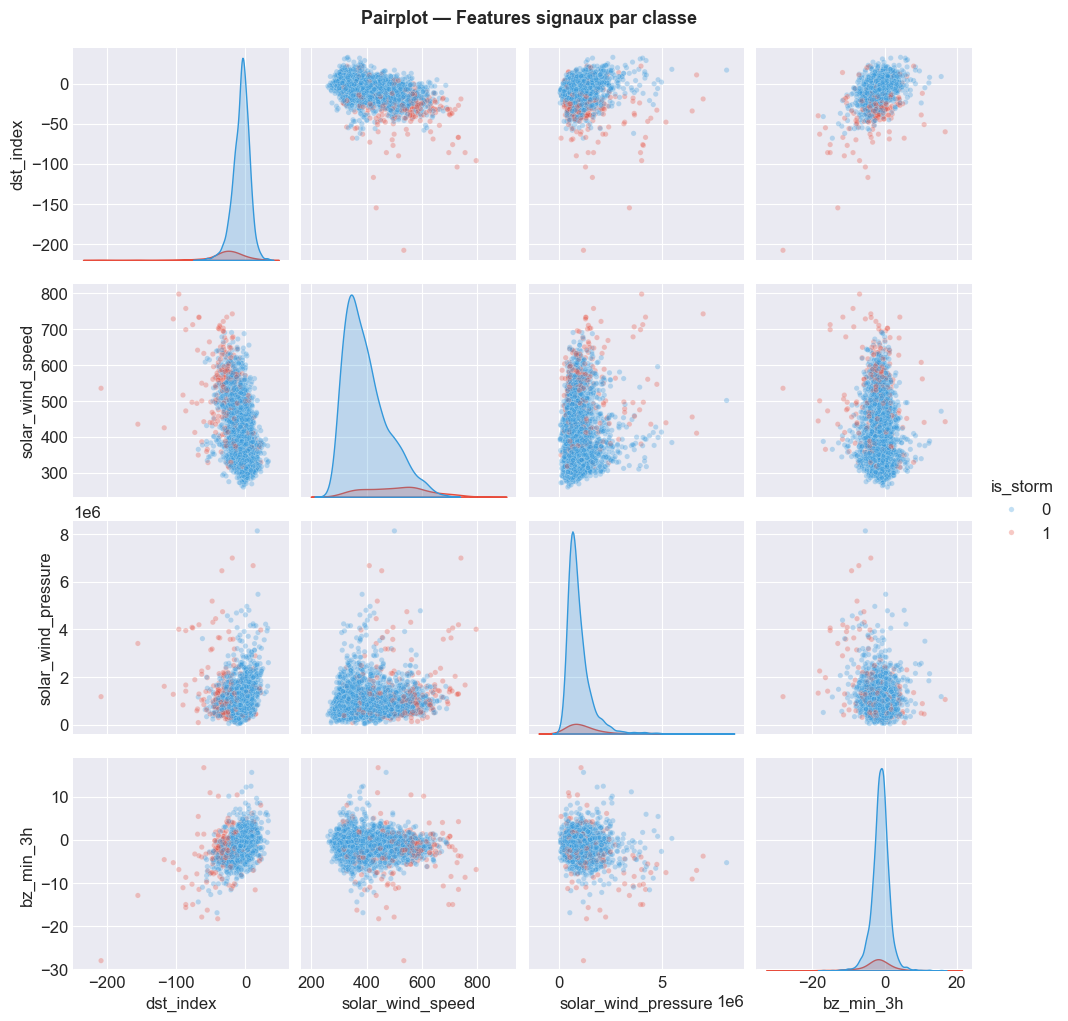

In [18]:
top_signals = corr_target[abs(corr_target) > 0.05].index.tolist()[:5]  # max 5 pour lisibilité
if len(top_signals) >= 2:
    sample = df[top_signals + [target]].dropna().sample(min(3000, len(df)), random_state=42)
    g = sns.pairplot(
        sample,
        hue=target,
        palette={0: '#3498DB', 1: '#E74C3C'},
        plot_kws={'alpha': 0.3, 's': 15},
        diag_kind='kde'
    )
    g.fig.suptitle('Pairplot — Features signaux par classe', y=1.02, fontsize=13, fontweight='bold')
    plt.savefig('../data/pairplot_signals.png', bbox_inches='tight')
    plt.show()
else:
    print('Pas assez de features signaux pour un pairplot.')

**Interprétation :**
- Le pairplot montre que les classes 'Tempête' (en rouge) se regroupent dans des zones spécifiques des plans factoriels, confirmant la séparabilité potentielle avec un bon modèle.